In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager, ShallowDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, NodeRFModel, NodeLSTMModel, GATv2Model

disease_name    = 'measles'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2017-06-01'
split_valtest   = '2018-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 1
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    # log_transform       = ['incidence','population_size'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'cases',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    
# data_orchestrator = DataOrchestrator(config).build()


data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )



/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataorchestrator    = (DataOrchestrator(config).build())
shallowdata         = ShallowDataLoaderManager(dataorchestrator).construct_dataloaders()
graphdataloader_id  = GraphDataLoaderManager(dataorchestrator).retrieve_graph('identity_graph').construct_dataloaders()
graphdataloader_bn  = GraphDataLoaderManager(dataorchestrator).retrieve_graph('geographical_neighbors1').construct_dataloaders()


==                     lstm                     ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.1941, val loss: 0.1141 ✓ (new best)
Epoch 2 train loss: 0.1691, val loss: 0.1066 ✓ (new best)
Epoch 3 train loss: 0.1343, val loss: 0.0921 ✓ (new best)
Epoch 4 train loss: 0.1105, val loss: 0.0910 ✓ (new best)
Epoch 5 train loss: 0.1059, val loss: 0.0918 (patience: 1/20)
Epoch 6 train loss: 0.1041, val loss: 0.0920 (patience: 2/20)
Epoch 7 train loss: 0.1023, val loss: 0.0920 (patience: 3/20)
Epoch 8 train loss: 0.1008, val loss: 0.0919 (patience: 4/20)
Epoch 9 train loss: 0.1004, val loss: 0.0918 (patience: 5/20)
Epoch 10 train loss: 0.0994, val loss: 0.0914 (patience: 6/20)
Epoch 11 train loss: 0.0987, val loss: 0.0909 ✓ (new best)
Epoch 12 train loss: 0.0967, val loss: 0.0902 ✓ (new best)
Epoch 13 train loss: 0.0958, val loss: 0.0902 (patience: 1/20)
Epoch 14 train loss: 0.0947, val loss: 0.0894 ✓ (new best)
Epoc

Forecasting test: 100%|████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 567.66it/s]


Test loss: 0.0844
additonal transformation


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

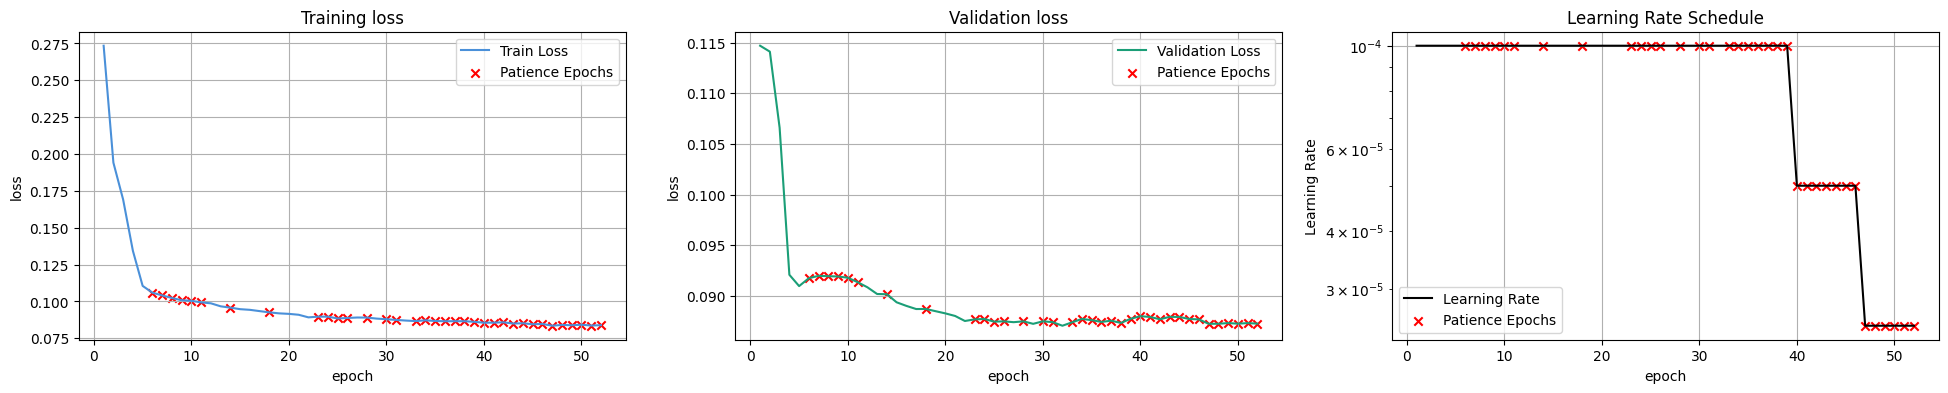

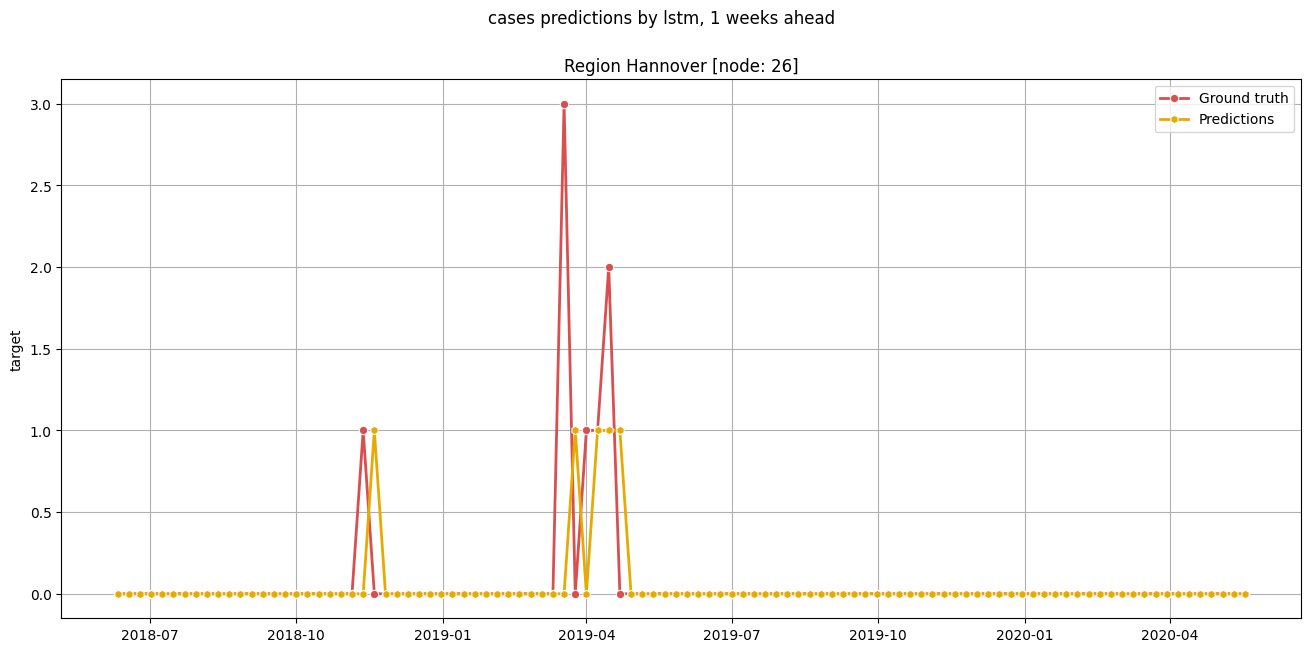

In [5]:
n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'poisson'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


lstm = NodeLSTMModel(graphdataloader_id, name = 'lstm')
lstm.set_model_hparams(hidden_size=128)
lstm.set_global_hparams(**global_hparams)
lstm.train(verbose = 2)
lstm.forecast('test')
lstm.show_forecasts(26)


==                   gcn - bn                   ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.1799, val loss: 0.1081 ✓ (new best)
Epoch 2 train loss: 0.1387, val loss: 0.1011 ✓ (new best)
Epoch 3 train loss: 0.1282, val loss: 0.0988 ✓ (new best)
Epoch 4 train loss: 0.1245, val loss: 0.0980 ✓ (new best)
Epoch 5 train loss: 0.1229, val loss: 0.0975 ✓ (new best)
Epoch 6 train loss: 0.1210, val loss: 0.0971 ✓ (new best)
Epoch 7 train loss: 0.1198, val loss: 0.0966 ✓ (new best)
Epoch 8 train loss: 0.1191, val loss: 0.0961 ✓ (new best)
Epoch 9 train loss: 0.1182, val loss: 0.0958 ✓ (new best)
Epoch 10 train loss: 0.1174, val loss: 0.0953 ✓ (new best)
Epoch 11 train loss: 0.1159, val loss: 0.0949 ✓ (new best)
Epoch 12 train loss: 0.1171, val loss: 0.0945 ✓ (new best)
Epoch 13 train loss: 0.1156, val loss: 0.0942 ✓ (new best)
Epoch 14 train loss: 0.1146, val loss: 0.0940 ✓ (new best)
Epoch 15 train loss: 0.1141, v

Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 627.60it/s]


Test loss: 0.0809
additonal transformation


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

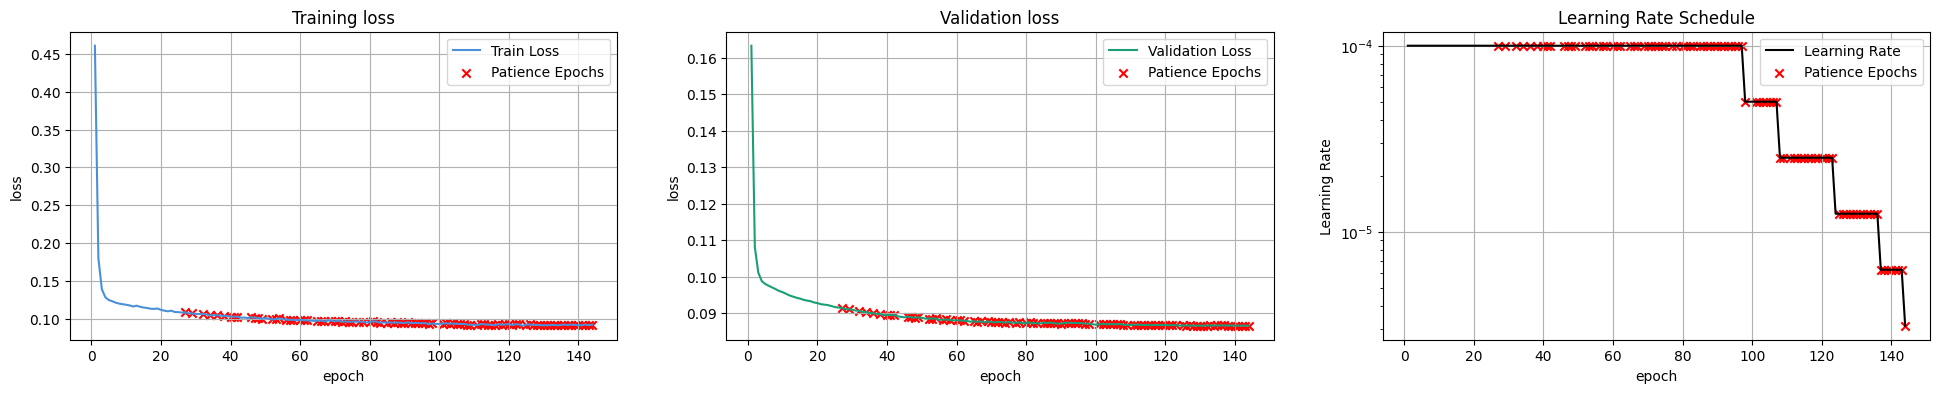

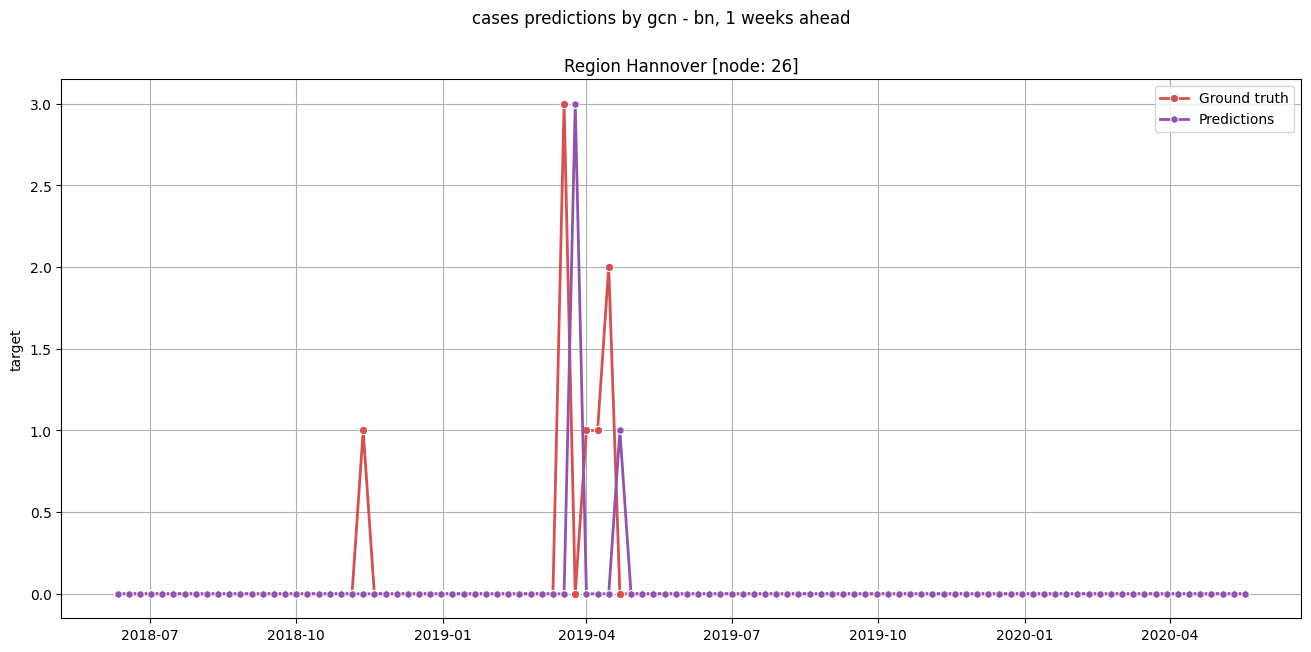

In [3]:
from src.models import SpatialGNNModel

n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'poisson'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


gcn = SpatialGNNModel(graphdataloader_bn, name = 'gcn - bn')
gcn.set_model_hparams()
gcn.set_global_hparams(**global_hparams)
gcn.train(verbose = 2)
gcn.forecast('test')
gcn.show_forecasts(26)


==                   gcn - bn                   ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.1982, val loss: 0.1139 ✓ (new best)
Epoch 2 train loss: 0.1540, val loss: 0.1043 ✓ (new best)
Epoch 3 train loss: 0.1360, val loss: 0.0996 ✓ (new best)
Epoch 4 train loss: 0.1257, val loss: 0.0975 ✓ (new best)
Epoch 5 train loss: 0.1216, val loss: 0.0968 ✓ (new best)
Epoch 6 train loss: 0.1209, val loss: 0.0965 ✓ (new best)
Epoch 7 train loss: 0.1207, val loss: 0.0961 ✓ (new best)
Epoch 8 train loss: 0.1190, val loss: 0.0958 ✓ (new best)
Epoch 9 train loss: 0.1188, val loss: 0.0955 ✓ (new best)
Epoch 10 train loss: 0.1162, val loss: 0.0950 ✓ (new best)
Epoch 11 train loss: 0.1159, val loss: 0.0948 ✓ (new best)
Epoch 12 train loss: 0.1150, val loss: 0.0944 ✓ (new best)
Epoch 13 train loss: 0.1148, val loss: 0.0942 ✓ (new best)
Epoch 14 train loss: 0.1141, val loss: 0.0939 ✓ (new best)
Epoch 15 train loss: 0.1129, v

Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 620.67it/s]


Test loss: 0.0843
additonal transformation


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

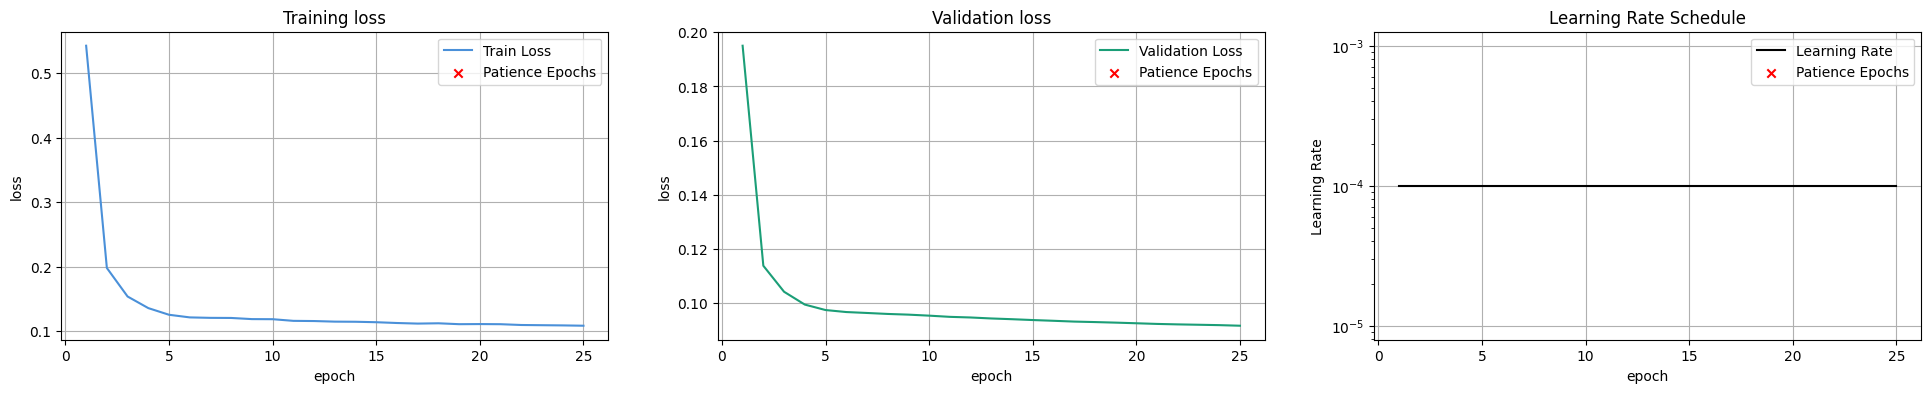

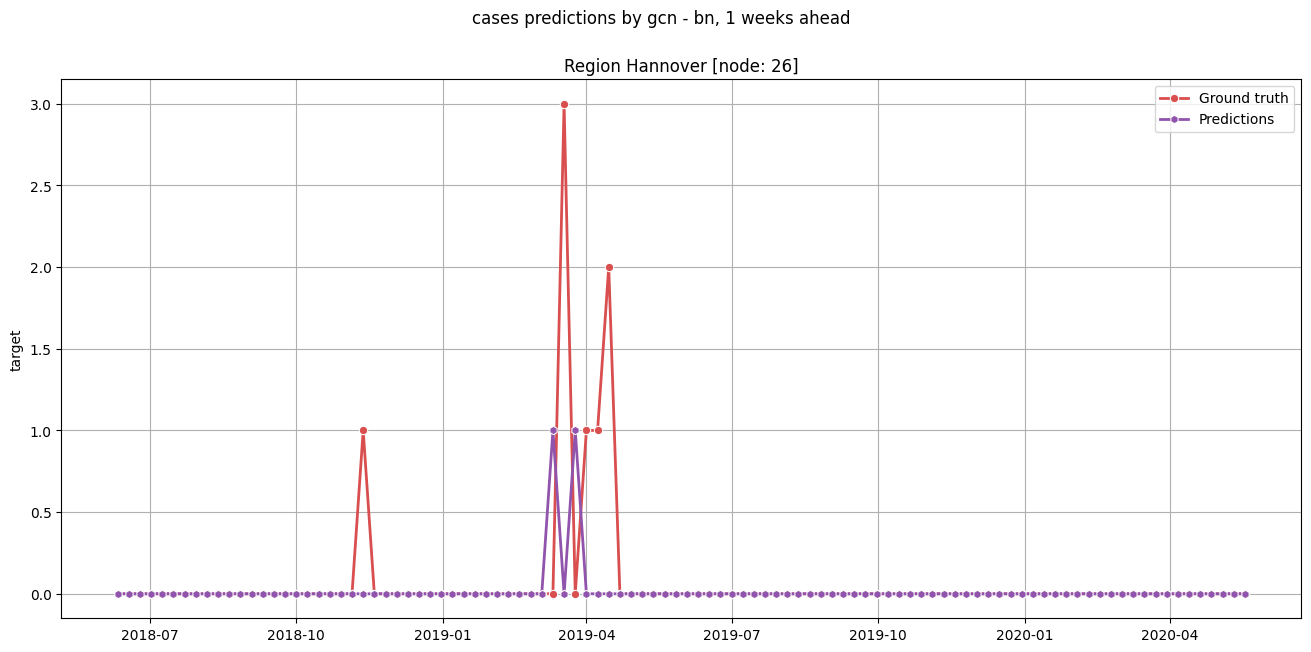

In [4]:
from src.models import SpatialGNNModel

n_epochs        = 25
lr              = 0.0001
min_delta       = 0.0001
loss            = 'poisson'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


gcn = SpatialGNNModel(graphdataloader_bn, name = 'gcn - bn')
gcn.set_model_hparams()
gcn.set_global_hparams(**global_hparams)
gcn.train(verbose = 2)
gcn.forecast('test')
gcn.show_forecasts(26)


==                   gat - bn                   ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2088), edge_weight=(2088,))
Epoch 1 train loss: 0.1254, val loss: 0.1012 ✓ (new best)
Epoch 2 train loss: 0.1091, val loss: 0.0995 ✓ (new best)
Epoch 3 train loss: 0.1050, val loss: 0.0949 ✓ (new best)
Epoch 4 train loss: 0.0999, val loss: 0.0936 ✓ (new best)
Epoch 5 train loss: 0.0981, val loss: 0.0932 ✓ (new best)
Epoch 6 train loss: 0.0958, val loss: 0.0911 ✓ (new best)
Epoch 7 train loss: 0.0934, val loss: 0.0890 ✓ (new best)
Epoch 8 train loss: 0.0924, val loss: 0.0889 ✓ (new best)
Epoch 9 train loss: 0.0905, val loss: 0.0880 ✓ (new best)
Epoch 10 train loss: 0.0879, val loss: 0.0873 ✓ (new best)
Epoch 11 train loss: 0.0887, val loss: 0.0876 (patience: 1/20)
Epoch 12 train loss: 0.0884, val loss: 0.0877 (patience: 2/20)
Epoch 13 train loss: 0.0847, val loss: 0.0865 ✓ (new best)
Epoch 14 train loss: 0.0841, val loss: 0.0862 ✓ (new best)
Epoch 15 train loss: 0

Forecasting test: 100%|████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 537.43it/s]


Test loss: 0.0722
additonal transformation


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

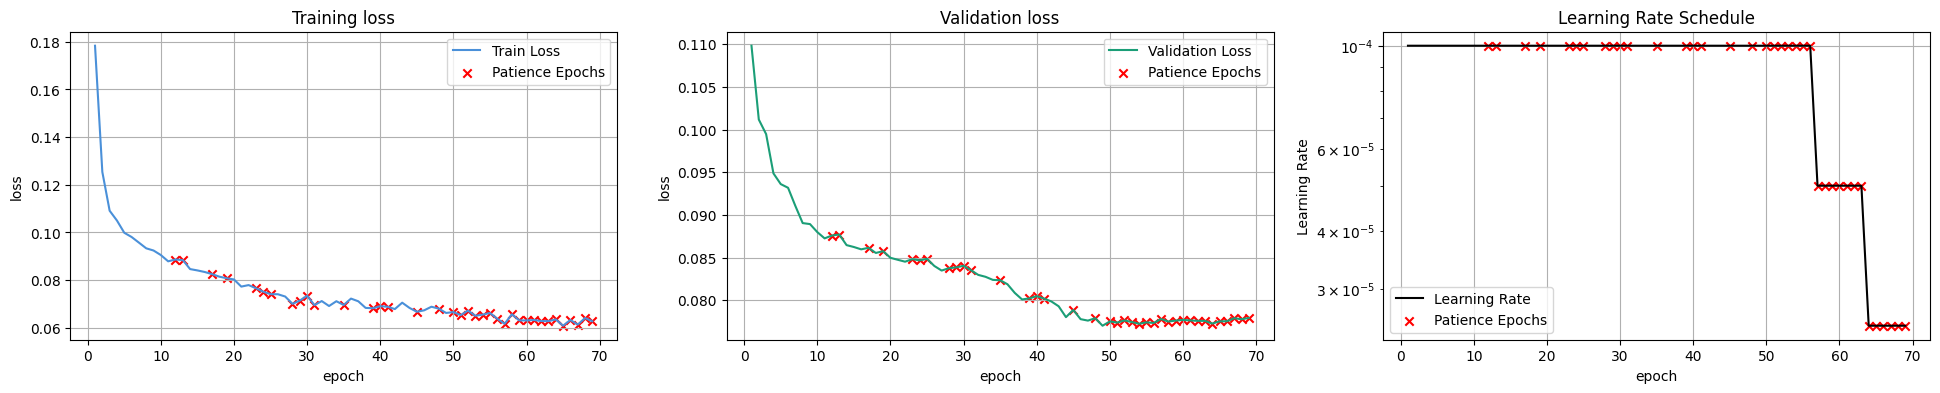

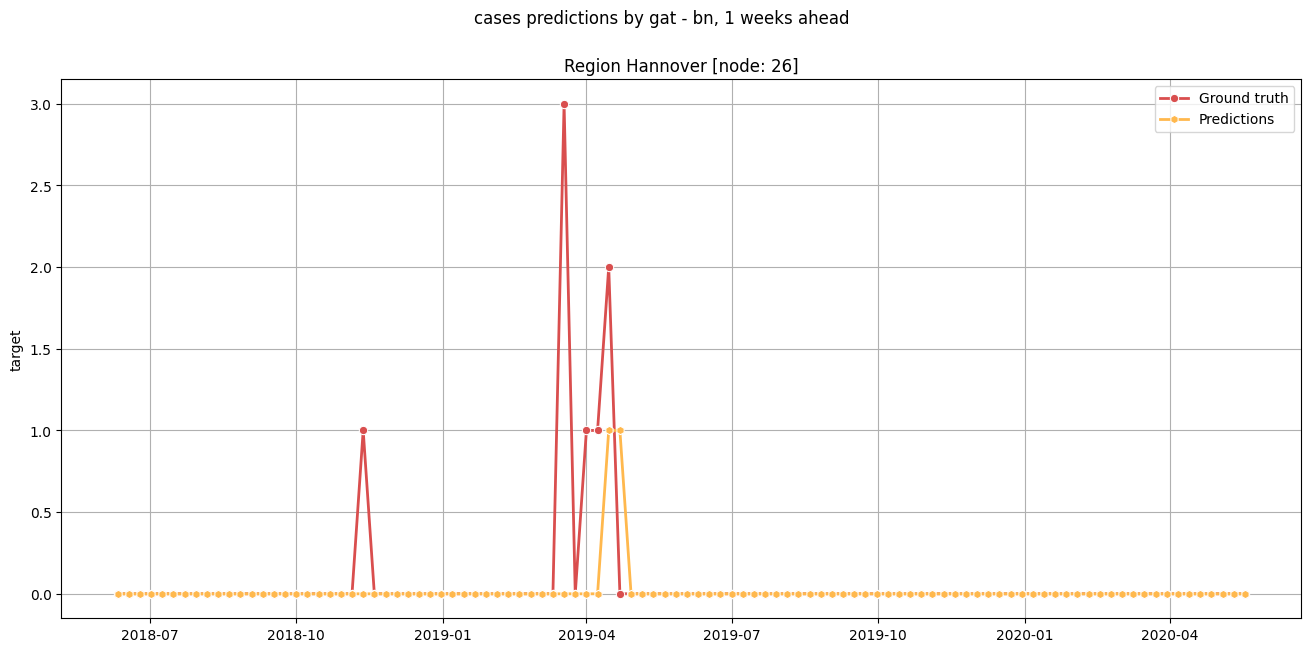

In [20]:
from src.models import GATv2Model

n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'poisson'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


gat = GATv2Model(graphdataloader_bn, name = 'gat - bn')
gat.set_model_hparams()
gat.set_global_hparams(**global_hparams)
gat.train(verbose = 2)
gat.forecast('test')
gat.show_forecasts(26)

(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'SK Oberhausen [node: 69]'}, ylabel='target'>])

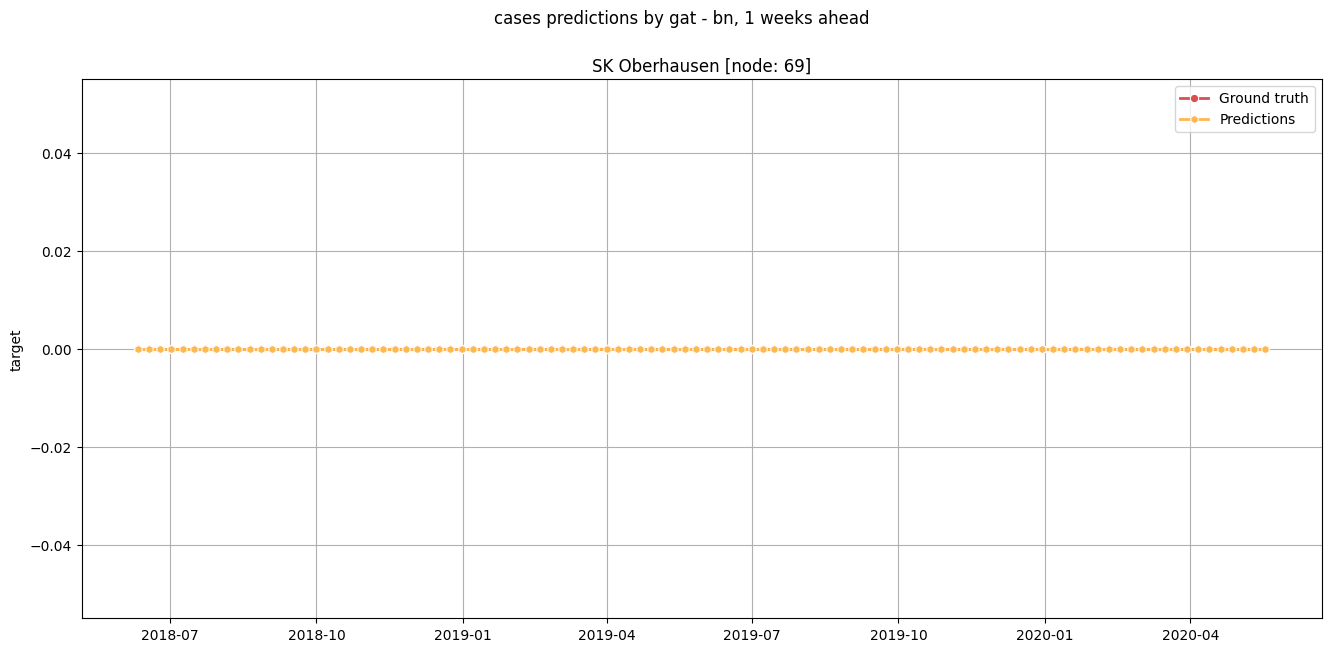

In [23]:
gat.show_forecasts(69)


==                   gcn - bn                   ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2088), edge_weight=(2088,))
Epoch 1 train loss: 0.4919, val loss: 0.3530 ✓ (new best)
Epoch 2 train loss: 0.4023, val loss: 0.3319 ✓ (new best)
Epoch 3 train loss: 0.3462, val loss: 0.3193 ✓ (new best)
Epoch 4 train loss: 0.3220, val loss: 0.3135 ✓ (new best)
Epoch 5 train loss: 0.3164, val loss: 0.3113 ✓ (new best)
Epoch 6 train loss: 0.3062, val loss: 0.3094 ✓ (new best)
Epoch 7 train loss: 0.3047, val loss: 0.3078 ✓ (new best)
Epoch 8 train loss: 0.3041, val loss: 0.3068 ✓ (new best)
Epoch 9 train loss: 0.3035, val loss: 0.3059 ✓ (new best)
Epoch 10 train loss: 0.2970, val loss: 0.3049 ✓ (new best)
Epoch 11 train loss: 0.2964, val loss: 0.3040 ✓ (new best)
Epoch 12 train loss: 0.2958, val loss: 0.3033 ✓ (new best)
Epoch 13 train loss: 0.2931, val loss: 0.3026 ✓ (new best)
Epoch 14 train loss: 0.2917, val loss: 0.3020 ✓ (new best)
Epoch 15 train loss: 0.2854, v

Forecasting test: 100%|████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 599.52it/s]


Test loss: 0.2661
additonal transformation


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

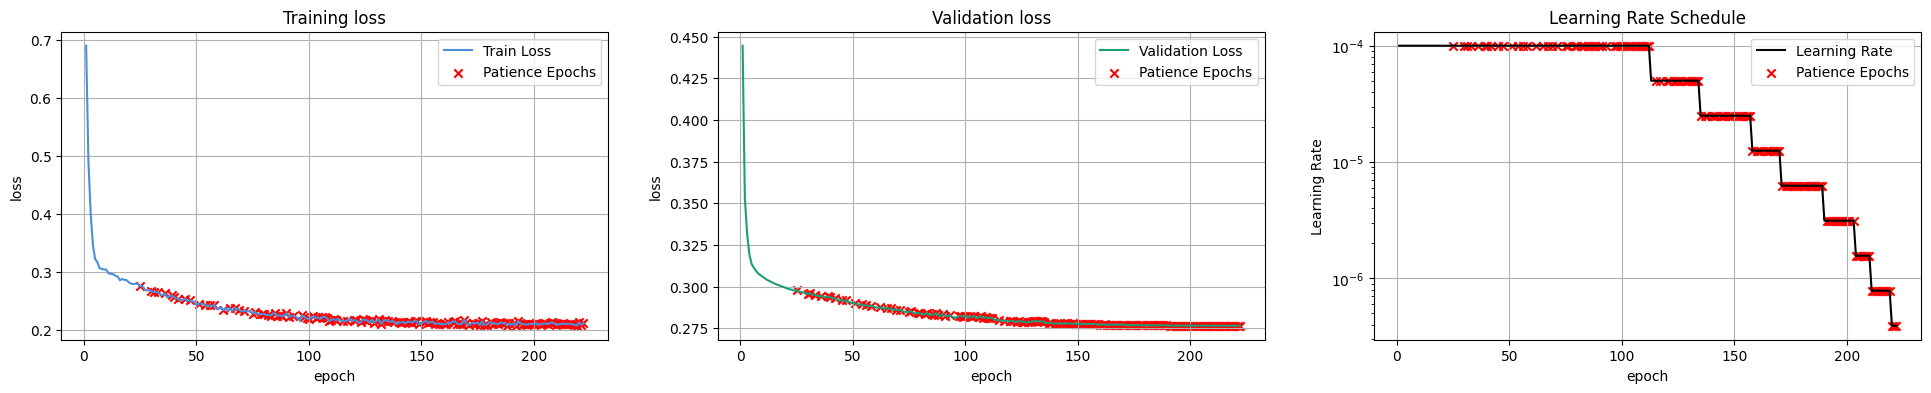

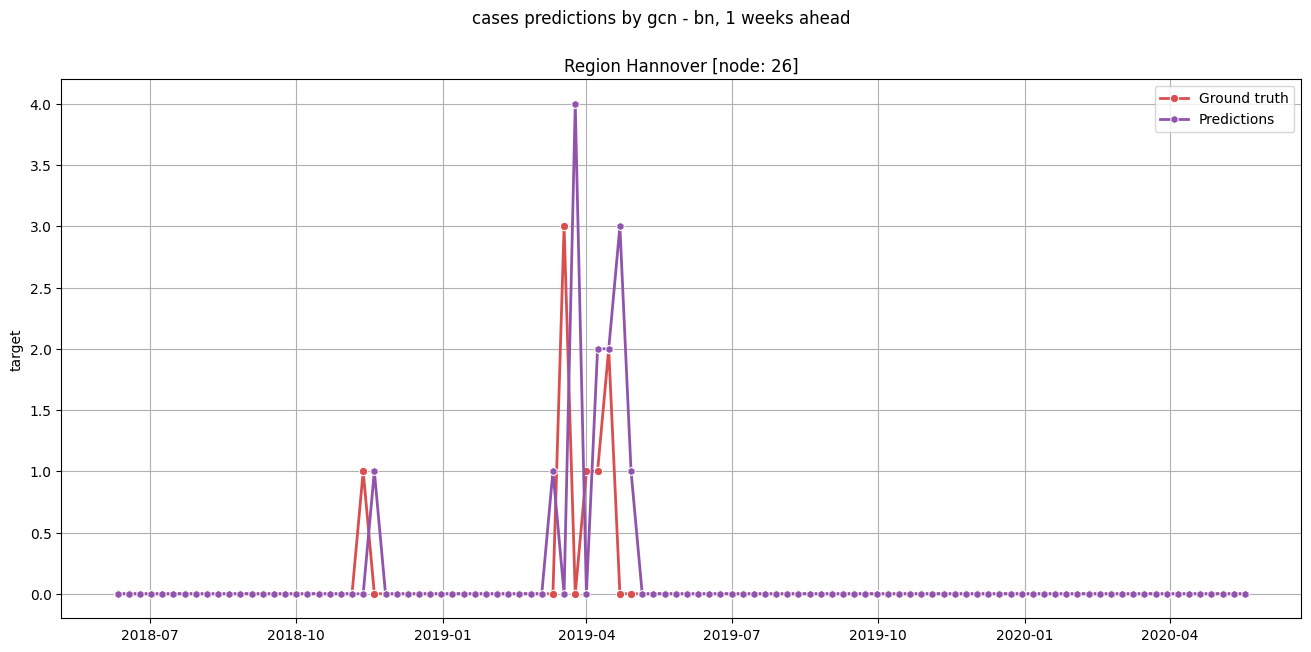

In [3]:
from src.models import SpatialGNNModel

n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'outbreakpoisson'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


gcn = SpatialGNNModel(graphdataloader_bn, name = 'gcn - bn')
gcn.set_model_hparams()
gcn.set_global_hparams(**global_hparams)
gcn.train(verbose = 2)
gcn.forecast('test')
gcn.show_forecasts(26)

(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'SK Hamburg [node: 15]'}, ylabel='target'>])

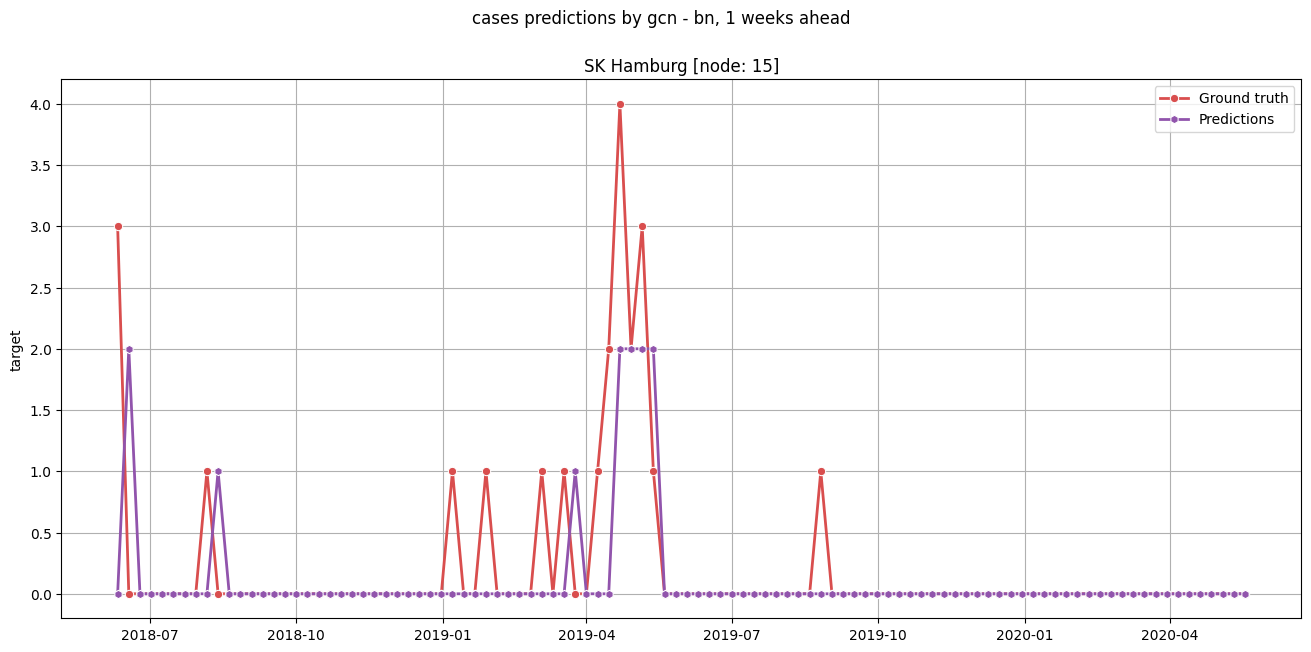

In [5]:
gcn.show_forecasts(15)